<a href="https://colab.research.google.com/github/4cekay/B101-Group2-NLP-Project/blob/main/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [ ]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate tensorboard scikit-learn

In [ ]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy, EarlyStoppingCallback
import torch
from sklearn.model_selection import train_test_split
import huggingface_hub
from collections import Counter
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json


# **Dataset**

Informal Dataset, Formal Dataset:
- (Aug 5): 5400 samples**
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - train_test_split (80/20) --> 4320 train / 1080 val

- Evaluation Set:
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - Additional 1350 samples (same informal/formal setting and human/AI classes, different models/sources) for external validation --> 5400 train / 1350 val


Load our .csv dataset file(s) and convert into HF dataset format.

In [ ]:
# original train_test_split set
path= r".\dataset\formal_set_5400.csv"
df= pd.read_csv(path)

raw_dataset= Dataset.from_pandas(df)
raw_dataset = raw_dataset.class_encode_column("AI_label") # encode the AI_label column into type ClassLabel

print(raw_dataset)


Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset({
    features: ['sample_text', 'sub-type', 'AI_label'],
    num_rows: 5400
})


Create 80/20 dataset split (shuffled, even class distribution)

**SKIP THIS FOR NOW, TRY THE STRAT SPLIT BELOW FIRST THANK YOU**

In [ ]:
dataset = raw_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True, stratify_by_column="AI_label")

# rename test set to val
dataset["val"] = dataset.pop("test")

dataset

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})

Either split it yourself with the full file,

In [ ]:
df = pd.read_csv("informal_samples.csv", encoding='latin-1')

# stratified split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['sub-type'],
    random_state=39
)

train_df.to_csv("train_subtype_stratified.csv", index=False)
val_df.to_csv("val_subtype_stratified.csv", index=False)

print(train_df)
print(train_df["sub-type"].value_counts(normalize=True))
print(train_df["AI_label"].value_counts(normalize=True))
print(val_df)
print(val_df["sub-type"].value_counts(normalize=True))
print(val_df["AI_label"].value_counts(normalize=True))

                                            sample_text       sub-type  \
3760  This small cafe near my apartment building has...         review   
5196  I keep forgetting to drink water, so IÕm tryin...  tweet/comment   
1333  This place was so neat! We had the cookies n' ...         review   
3907  Checked out the bowling alley we went to recen...         review   
4386  Bought a new yoga mat and tested it during a h...         review   
...                                                 ...            ...   
5084  Shut up you stupid idiot, your comments are th...  tweet/comment   
4353  Bought a small lamp and itÕs been useful for r...         review   
3903  Tried out the comedy show downtown this week a...         review   
5208  I need to stop buying random snacks, but they ...  tweet/comment   
152        umma my life and vava umma love you lot dear        message   

      AI_label  
3760         1  
5196         1  
1333         0  
3907         1  
4386         1  
...      

or load the stratified splits into a dataset object

In [ ]:
strat_split = {
    "train": "train_subtype_stratified.csv",
    "val": "val_subtype_stratified.csv"
}

# load it as a ready dataset object
dataset_stratified = load_dataset("csv", data_files=strat_split)

Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

(ignore this don't bother)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Load stratified train/val splits
train_df = pd.read_csv("train_subtype_stratified.csv")
val_df = pd.read_csv("val_subtype_stratified.csv")

# Combine and mark split
df = pd.concat([
    train_df.assign(split=0),
    val_df.assign(split=1)
], ignore_index=True)

# Vectorize text
vec = TfidfVectorizer(
    ngram_range=(1,3),
    max_features=50000,
    min_df=2
)
X = vec.fit_transform(df['sample_text'])
y = df['split'].values  # 0=train, 1=val

# Logistic regression classifier
clf = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='saga'
)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc = cross_val_score(clf, X, y, cv=cv, scoring='accuracy').mean()
auc = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc').mean()

print(f"Adversarial accuracy: {acc:.3f}")
print(f"Adversarial ROC AUC: {auc:.3f}")


Adversarial accuracy: 0.716
Adversarial ROC AUC: 0.464


# **Fine-Tuning Prep**

## **Tokenization**

In [ ]:
# Load tokenizer needed by the base model

model = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model, use_fast=True)

tokenizer

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

**Note: **DeBERTa V3 uses SentencePiece tokenization instead of Standard BPE and Unigram, which tokenizes raw characters (rather than getting treated like a boundary to help create words) >>> token count != word count.

In [ ]:
def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=350) # 512 is the max, though the dataset should be safe enough from cleaning
  tokenized["labels"] = example["AI_label"]
  return tokenized

In [ ]:
tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=["sample_text", "sub-type", "AI_label"])
tokenized_dataset

Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 1080
    })
})

## **Metrics**

### **Functions Setup** (compute_metrics)

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis=-1)
  accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
  f1 = f1_metric.compute(predictions=predictions, references=labels)
  return {**accuracy, **f1}

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # Accuracy
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    # Precision, Recall, F1 (macro + weighted)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    # ROC AUC
    try:
        auc = roc_auc_score(labels, logits[:,1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision,
        "recall_macro": recall,
        "auc": auc,
    }

### **SKLearn Metric Graphs**

In [ ]:
# metric charts from logged steps in "best model" checkpoints

output_dir = './metric_graphs_newest'
os.makedirs(output_dir, exist_ok=True)

trainer_state_path = "trainer_state.json"
trainer_state = json.load(file)

log_history = trainer_state.get('log_history', [])

# training vs. val steps
train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

# extract training metrics
train_steps = [log['step'] for log in train_logs]
train_loss = [log['loss'] for log in train_logs]
train_learning_rate = [log['learning_rate'] for log in train_logs]

# extract evaluation metrics
eval_steps = [log['step'] for log in eval_logs]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]
eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]

sns.set_theme(style="whitegrid")

# train loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_loss, marker='o', color='skyblue')
plt.title('Training Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(os.path.join(output_plot_dir, 'training_loss.png'))
plt.show()

# eval loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_loss, marker='o', color='salmon')
plt.title('Evaluation Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Evaluation Loss')
plt.grid(True)
plt.savefig(os.path.join(output_plot_dir, 'eval_loss.png'))
plt.show()

# eval acc
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_accuracy, marker='o', color='lightgreen')
plt.title('Evaluation Accuracy over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig(os.path.join(output_plot_dir, 'eval_accuracy.png'))
plt.show()

# eval F1 (macro)
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_f1_macro, marker='o', color='gold')
plt.title('Evaluation F1-Macro over Steps')
plt.xlabel('Training Steps')
plt.ylabel('F1-Macro Score')
plt.grid(True)
plt.savefig(os.path.join(output_plot_dir, 'eval_f1_macro.png'))
plt.show()

# plot learning rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_learning_rate, marker='o', color='purple')
plt.title('Learning Rate over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.savefig(os.path.join(output_plot_dir, 'learning_rate.png'))
plt.show()

## **Training Config**

In [ ]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}

model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    dtype=torch.float32, # very important T^T she blows up and dies otherwise
    hidden_dropout_prob=0.15,          # trial, default is 0.1
    attention_probs_dropout_prob=0.15, # trial, default is 0.1
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    seed=42,
    output_dir="./deberta_v3_small_results_2",
    logging_dir="./logs",
    logging_steps=20,
    report_to = "tensorboard",

    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1e-5,
    weight_decay=0.01,

    lr_scheduler_type="linear",
    warmup_ratio=0.1,

    eval_strategy="epoch",  # can change to epoch/steps
    eval_steps = 50,
    save_strategy="epoch",
    save_steps = 50,
    save_total_limit = 2,

    max_grad_norm=1.0,
    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    metric_for_best_model="f1",
    greater_is_better=True,
    load_best_model_at_end=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # patience, for early stop
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifie

# **Fine-Tuning an AI-Text Detector**

## **Tensorboard**
For viewing train/eval metrics + graphs

**Local:**

Not sure on Google runtime, but locally, it times out in the notebook for me so I don't recommend running it here.

- In command line/terminal, go to your working directory
- **tensorboard --logdir=./logs --port=6006**
- Access localhost in browser


## **Prelim Settings Rerun**

To retrieve proper metrics (tensorboard bug) and save run (lost logs to crash).
- Note: Specifically BEFORE dtype fix, so collapsing results are expected.

In [ ]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    dtype=torch.float32 # change
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_small_dtype",
    logging_dir="./logs/dtype",
    logging_steps=20,

    report_to = "tensorboard",

    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.05,

    lr_scheduler_type="linear",
    warmup_steps=50,

    eval_strategy="steps",
    eval_steps = 85,
    save_strategy="steps",
    save_steps = 85,
    save_total_limit = 2,

    max_grad_norm=1.0,
    fp16=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,
    load_best_model_at_end=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifie

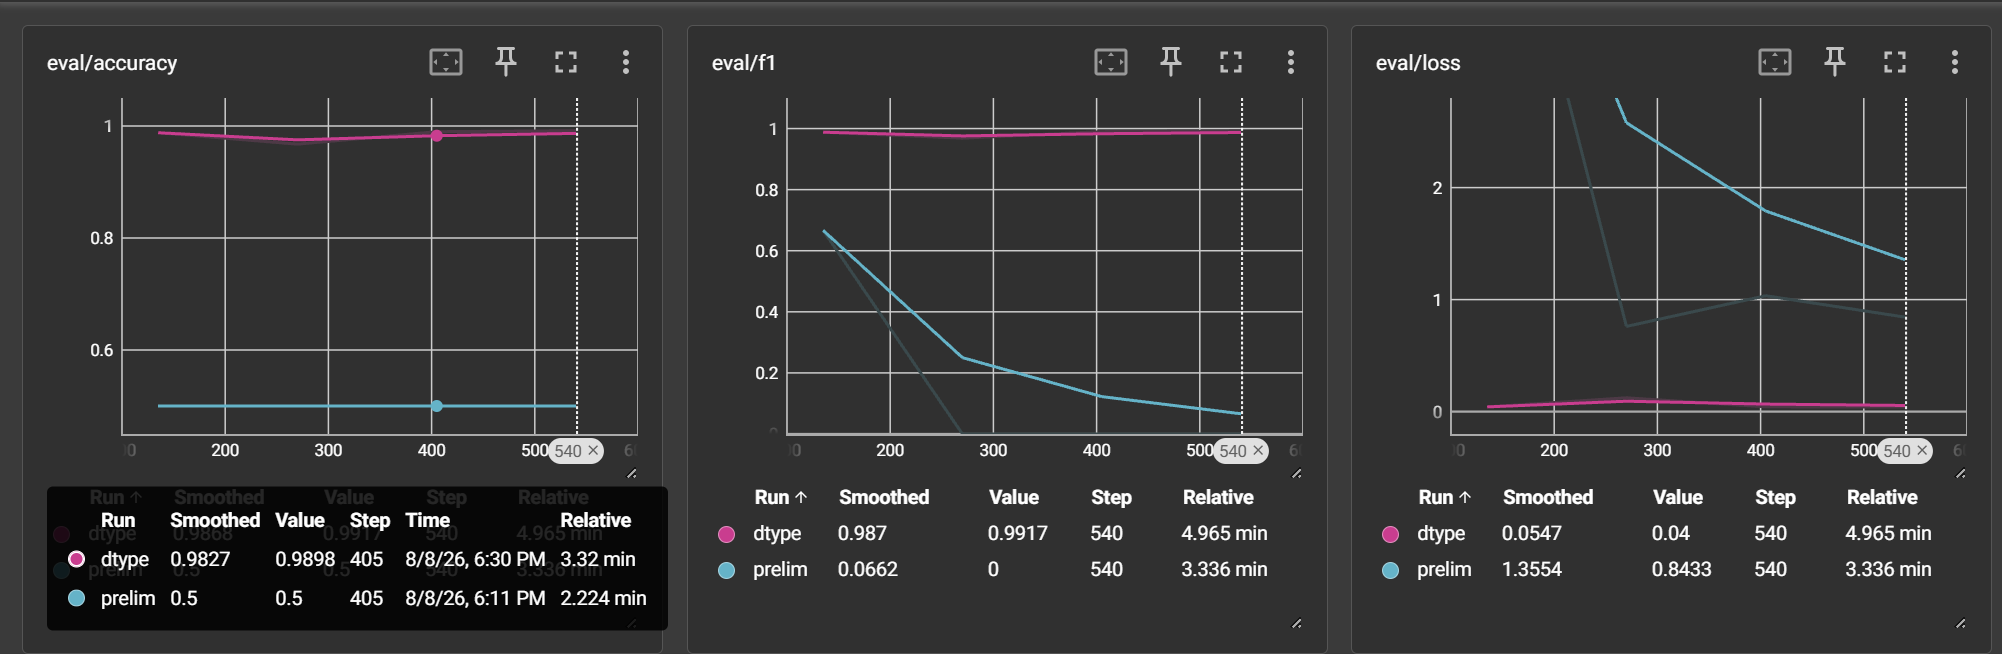

Prelim Run (post-fp16, emergency dataset cleaning fixes) on Formal Dataset

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
50,0.694851,0.683622,0.500000,0.000000
100,0.321564,0.243215,0.898148,0.902998
150,0.208967,0.113891,0.962037,0.963360
200,0.058592,0.074021,0.978704,0.978995
250,0.047767,0.146977,0.968519,0.969424
300,0.027279,0.060348,0.986111,0.986276
350,0.052604,0.035808,0.989815,0.989843
400,0.001787,0.051619,0.987963,0.988040
450,0.082203,0.040964,0.990741,0.990689
500,0.037807,0.081352,0.984259,0.984389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1080, training_loss=0.0884912511323044, metrics={'train_runtime': 1297.1526, 'train_samples_per_second': 13.321, 'train_steps_per_second': 0.833, 'total_flos': 2289118186045440.0, 'train_loss': 0.0884912511323044, 'epoch': 4.0})

# **Evaluation on External Data**

External Test Set: 1350 samples, mixed genre, outside sources

In [ ]:
# tokenizing the external evaluation set
external_df = pd.read_csv("./dataset/formal_val_1350.csv") # evaluation set
external_dataset = Dataset.from_pandas(external_df)

checkpoint_dir = "./runs/deberta_v3_small_dtype" # folder to model you're loading
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir,dtype=torch.float32)
model.eval()

MAX_LENGTH = 350 # make sure this value matches the max length used by the model you're evaluating

def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
  tokenized["labels"] = example["AI_label"]
  return tokenized

tokenized_external_dataset = external_dataset.map(
    tokenize,
    batched=True,
    remove_columns=external_dataset.column_names,
)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=32,
    report_to="none",
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
)

In [ ]:
# run prediction

preds_output = eval_trainer.predict(tokenized_external_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1] # AI probability / confidence
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

In [ ]:
results_df = pd.DataFrame({
    "text": external_df["sample_text"].values,
    "true_label": labels,
    "pred_label": predicted_classes,
    "prob_ai": prob_ai,
    "sub-type": external_df["sub-type"].values if "sub-type" in external_df.columns else None,
})

# Informal Train + Evaluation for Hung and Mahla

Jeffrey's Optuna setup

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32
)

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./deberta_v3_best",

    # Optuna Best Parameters
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

# Run full final training run
trainer.train()

# Save final tuned model weights and tokenizer
trainer.save_model("./deberta_v3_informal")
tokenizer.save_pretrained("./deberta_v3_informal_fin")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifie

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
45,0.696326,0.691998,0.501852,0.334155,0.335393,0.250926,0.500000,0.877653
90,0.677965,0.662460,0.937037,0.937029,0.937032,0.937153,0.937009,0.981589
135,0.315722,0.224563,0.966667,0.966657,0.966659,0.967022,0.966618,0.993806
180,0.144418,0.243847,0.952778,0.952703,0.952696,0.956099,0.952938,0.988292
225,0.106731,0.187101,0.971296,0.971283,0.971281,0.972395,0.971388,0.992508
270,0.105789,0.129052,0.990741,0.990741,0.990741,0.990754,0.990754,0.995974
315,0.112266,0.135015,0.987963,0.987963,0.987963,0.988022,0.987987,0.995470
360,0.131499,0.147144,0.982407,0.982406,0.982406,0.982645,0.982452,0.992995
405,0.119435,0.169873,0.976852,0.976846,0.976845,0.977508,0.976924,0.991238
450,0.102830,0.133706,0.988889,0.988889,0.988889,0.988929,0.988909,0.994194


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./deberta_v3_informal_fin\\tokenizer_config.json',
 './deberta_v3_informal_fin\\tokenizer.json')

In [ ]:
# tokenizing the external evaluation set
external_df = pd.read_csv("outsideval_informal_samples.csv", encoding="Latin-1") # evaluation set
external_dataset = Dataset.from_pandas(external_df)

checkpoint_dir = r".\deberta_v3_best\checkpoint-270" # folder to model you're loading
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir,dtype=torch.float32)
model.eval()

MAX_LENGTH = 350 # make sure this value matches the max length used by the model you're evaluating

def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=MAX_LENGTH)
  tokenized["labels"] = example["AI_label"]
  return tokenized

tokenized_external_dataset = external_dataset.map(
    tokenize,
    batched=True,
    remove_columns=external_dataset.column_names,
)

eval_args = TrainingArguments(
    output_dir="./tmp_eval",
    per_device_eval_batch_size=32,
    report_to="none",
)

eval_trainer = Trainer(
    model=model,
    args=eval_args,
)

preds_output = eval_trainer.predict(tokenized_external_dataset)
logits = preds_output.predictions
labels = preds_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]  # P(AI-generated) — this is what roc_auc_score needs as y_score
predicted_classes = np.argmax(logits, axis=-1)

# quick metric breakdown

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))

print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))

print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))
print(external_df["AI_label"].value_counts())

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({0: 1350})
AUC: 0.37400823045267495
F1: 0.0
Confusion matrix:
 [[675   0]
 [675   0]]


In [ ]:
results_df = pd.DataFrame({
    "text": external_df["sample_text"].values,
    "true_label": labels,
    "pred_label": predicted_classes,
    "prob_ai": prob_ai,
    "sub-type": external_df["sub-type"].values if "sub-type" in external_df.columns else None,
})